##  Импорты и настройки

In [2]:
import requests
import pandas as pd
import time
import json

# Сюда вставишь когда придёт одобрение
CLIENT_ID = "OPCOR0ADLPGO3L7S5CBP2LHF8USANGIAT478PA130P2HLN1LR0KOPLNHRGDFIR34"
CLIENT_SECRET = "GGE0442E1P7JOU26AHP64S35883TGQ545P0BF17P205IRP0FJ2A45799J3ABMORM"

# Параметры сбора
SEARCH_QUERIES = [
    "аналитик данных",
    "data analyst", 
    "BI аналитик",
    "бизнес аналитик"
]

AREA = 113  # Россия
PER_PAGE = 100
MAX_PAGES = 20  # максимум 2000 вакансий на запрос

## Получения токена

In [4]:
def get_token(client_id, client_secret):
    url = "https://hh.ru/oauth/token"
    data = {
        "grant_type": "client_credentials",
        "client_id": client_id,
        "client_secret": client_secret
    }
    response = requests.post(url, data=data)
    print("Статус:", response.status_code)
    print("Ответ:", response.json())
    return response.json().get("access_token")

token = get_token(CLIENT_ID, CLIENT_SECRET)
print("Токен:", token)

Статус: 200
Ответ: {'access_token': 'APPLI3V3SFC6KLVG9T2PA57HAB2PT5H7E4A3NPEDJHFKOJPFOUEUF3PEVF1BEGVH', 'token_type': 'bearer'}
Токен: APPLI3V3SFC6KLVG9T2PA57HAB2PT5H7E4A3NPEDJHFKOJPFOUEUF3PEVF1BEGVH


## Сбор вакансий

In [5]:
def collect_vacancies(query, token, pages=5):
    headers = {
        "Authorization": f"Bearer {token}",
        "User-Agent": "hh_vacancy_parser/1.0 (gebel@internet.ru)"
    }
    all_vacancies = []
    
    for page in range(pages):
        params = {
            "text": query,
            "area": AREA,
            "per_page": PER_PAGE,
            "page": page
        }
        response = requests.get(
            "https://api.hh.ru/vacancies",
            params=params,
            headers=headers
        )
        data = response.json()
        items = data.get("items", [])
        all_vacancies.extend(items)
        
        print(f"Запрос: '{query}' | Страница {page+1} | Вакансий: {len(items)}")
        time.sleep(0.5)
        
        if page >= data.get("pages", 0) - 1:
            break
    
    return all_vacancies

# Тест на одном запросе
test = collect_vacancies("аналитик данных", token, pages=2)
print(f"\nВсего собрано: {len(test)} вакансий")
print(f"Пример: {test[0]['name']} — {test[0]['employer']['name']}")

Запрос: 'аналитик данных' | Страница 1 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 2 | Вакансий: 100

Всего собрано: 200 вакансий
Пример: Аналитик данных — КАША.РУ


### Собираем данные 

In [6]:
# Собираем все вакансии
all_data = []

for query in SEARCH_QUERIES:
    vacancies = collect_vacancies(query, token, pages=MAX_PAGES)
    for v in vacancies:
        all_data.append({
            "query": query,
            "id": v.get("id"),
            "name": v.get("name"),
            "employer": v.get("employer", {}).get("name"),
            "area": v.get("area", {}).get("name"),
            "salary_from": v.get("salary", {}).get("from") if v.get("salary") else None,
            "salary_to": v.get("salary", {}).get("to") if v.get("salary") else None,
            "currency": v.get("salary", {}).get("currency") if v.get("salary") else None,
            "experience": v.get("experience", {}).get("name"),
            "employment": v.get("employment", {}).get("name"),
            "schedule": v.get("schedule", {}).get("name"),
            "url": v.get("alternate_url"),
            "published_at": v.get("published_at"),
        })
    print(f"✅ '{query}' — собрано {len(vacancies)} вакансий")

# Создаём DataFrame
df = pd.DataFrame(all_data)

# Убираем дубли по id
df = df.drop_duplicates(subset="id")

print(f"\nИтого уникальных вакансий: {len(df)}")
print(df.head())

Запрос: 'аналитик данных' | Страница 1 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 2 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 3 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 4 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 5 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 6 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 7 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 8 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 9 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 10 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 11 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 12 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 13 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 14 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 15 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 16 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 17 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 18 | Вакансий: 100
З

In [7]:
# Сохраняем в CSV
df.to_csv("hh_vacancies.csv", index=False, encoding="utf-8-sig")
print("Файл сохранён: hh_vacancies.csv")

# Базовая статистика
print(f"\nВсего вакансий: {len(df)}")
print(f"\nПо запросам:")
print(df['query'].value_counts())
print(f"\nТоп городов:")
print(df['area'].value_counts().head(10))
print(f"\nОпыт работы:")
print(df['experience'].value_counts())
print(f"\nВакансий с зарплатой: {df['salary_from'].notna().sum()} ({df['salary_from'].notna().mean()*100:.1f}%)")

Файл сохранён: hh_vacancies.csv

Всего вакансий: 5582

По запросам:
query
аналитик данных    1999
data analyst       1333
BI аналитик        1271
бизнес аналитик     979
Name: count, dtype: int64

Топ городов:
area
Москва             3525
Санкт-Петербург     563
Екатеринбург        127
Новосибирск         113
Казань              102
Нижний Новгород      97
Краснодар            82
Самара               47
Воронеж              41
Ростов-на-Дону       41
Name: count, dtype: int64

Опыт работы:
experience
От 3 до 6 лет         2423
От 1 года до 3 лет    2354
Более 6 лет            481
Нет опыта              324
Name: count, dtype: int64

Вакансий с зарплатой: 1743 (31.2%)


In [8]:
# Чистка данных
df['published_at'] = pd.to_datetime(df['published_at'])
df['date'] = df['published_at'].dt.date

# Удалённая работа
df['is_remote'] = df['schedule'].str.contains('Удалённая', na=False)

# Средняя зарплата
df['salary_avg'] = df[['salary_from', 'salary_to']].mean(axis=1)

# Краснодар отдельно
df_krd = df[df['area'] == 'Краснодар']

print(f"Вакансий в Краснодаре: {len(df_krd)}")
print(f"Удалённых вакансий всего: {df['is_remote'].sum()}")
print(f"\nОпыт в Краснодаре:")
print(df_krd['experience'].value_counts())
print(f"\nЗарплаты (руб) — медиана по рынку:")
print(df.groupby('experience')['salary_avg'].median().round(0))

Вакансий в Краснодаре: 82
Удалённых вакансий всего: 0

Опыт в Краснодаре:
experience
От 1 года до 3 лет    49
От 3 до 6 лет         29
Нет опыта              4
Name: count, dtype: int64

Зарплаты (руб) — медиана по рынку:
experience
Более 6 лет           250000.0
Нет опыта              80000.0
От 1 года до 3 лет    110000.0
От 3 до 6 лет         185000.0
Name: salary_avg, dtype: float64


In [9]:
# Проверяем значения в schedule
print(df['schedule'].value_counts())
print(df['employment'].value_counts())

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


In [10]:
# Смотрим первую вакансию полностью
import json
print(json.dumps(test[0], ensure_ascii=False, indent=2))

{
  "id": "133222123",
  "premium": false,
  "name": "Аналитик данных",
  "department": null,
  "has_test": false,
  "response_letter_required": false,
  "area": {
    "id": "1",
    "name": "Москва",
    "url": "https://api.hh.ru/areas/1"
  },
  "salary": null,
  "salary_range": null,
  "type": {
    "id": "open",
    "name": "Открытая"
  },
  "address": {
    "city": "Москва",
    "street": "проезд Дежнёва",
    "building": "1",
    "lat": 55.871173,
    "lng": 37.649849,
    "description": null,
    "raw": "Москва, проезд Дежнёва, 1",
    "metro": {
      "station_name": "Медведково",
      "line_name": "Калужско-Рижская",
      "station_id": "6.81",
      "line_id": "6",
      "lat": 55.888103,
      "lng": 37.661562,
      "hex_color": "F07E24"
    },
    "metro_stations": [
      {
        "station_name": "Медведково",
        "line_name": "Калужско-Рижская",
        "station_id": "6.81",
        "line_id": "6",
        "lat": 55.888103,
        "lng": 37.661562,
        "hex_col

In [11]:
# Пересобираем данные с правильными полями
all_data2 = []

for query in SEARCH_QUERIES:
    vacancies = collect_vacancies(query, token, pages=MAX_PAGES)
    for v in vacancies:
        # Формат работы (удалёнка, офис и т.д.)
        work_formats = [wf['name'] for wf in v.get('work_format', [])]
        
        all_data2.append({
            "query": query,
            "id": v.get("id"),
            "name": v.get("name"),
            "employer": v.get("employer", {}).get("name"),
            "area": v.get("area", {}).get("name"),
            "salary_from": v.get("salary", {}).get("from") if v.get("salary") else None,
            "salary_to": v.get("salary", {}).get("to") if v.get("salary") else None,
            "currency": v.get("salary", {}).get("currency") if v.get("salary") else None,
            "experience": v.get("experience", {}).get("name"),
            "work_format": ", ".join(work_formats),
            "is_remote": any(wf.get("id") == "REMOTE" for wf in v.get("work_format", [])),
            "employment_form": v.get("employment_form", {}).get("name"),
            "url": v.get("alternate_url"),
            "published_at": v.get("published_at"),
        })

df = pd.DataFrame(all_data2).drop_duplicates(subset="id")
df['published_at'] = pd.to_datetime(df['published_at'])
df['salary_avg'] = df[['salary_from', 'salary_to']].mean(axis=1)

print(f"Всего вакансий: {len(df)}")
print(f"\nФорматы работы:")
print(df['work_format'].value_counts().head(10))
print(f"\nУдалённых: {df['is_remote'].sum()}")
print(f"Удалённых в Краснодаре: {df[(df['is_remote']) & (df['area']=='Краснодар')].shape[0]}")

Запрос: 'аналитик данных' | Страница 1 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 2 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 3 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 4 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 5 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 6 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 7 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 8 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 9 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 10 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 11 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 12 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 13 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 14 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 15 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 16 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 17 | Вакансий: 100
Запрос: 'аналитик данных' | Страница 18 | Вакансий: 100
З

In [12]:
# Анализ удалённых вакансий
df_remote = df[df['is_remote']]

print("=== УДАЛЁННЫЕ ВАКАНСИИ ===")
print(f"\nПо опыту:")
print(df_remote['experience'].value_counts())

print(f"\nМедиана зарплат удалённо (руб):")
print(df_remote.groupby('experience')['salary_avg'].median().round(0))

print(f"\nТоп городов для удалёнки:")
print(df_remote['area'].value_counts().head(10))

print(f"\n=== КРАСНОДАР — удалённые ===")
df_krd_remote = df[(df['is_remote']) & (df['area']=='Краснодар')]
print(df_krd_remote[['name', 'employer', 'experience', 'salary_from', 'salary_to', 'url']])

=== УДАЛЁННЫЕ ВАКАНСИИ ===

По опыту:
experience
От 3 до 6 лет         740
От 1 года до 3 лет    556
Более 6 лет           166
Нет опыта              81
Name: count, dtype: int64

Медиана зарплат удалённо (руб):
experience
Более 6 лет           250000.0
Нет опыта              60000.0
От 1 года до 3 лет    100000.0
От 3 до 6 лет         200000.0
Name: salary_avg, dtype: float64

Топ городов для удалёнки:
area
Москва             1053
Санкт-Петербург     159
Екатеринбург         40
Казань               37
Нижний Новгород      31
Новосибирск          29
Краснодар            20
Самара               13
Ростов-на-Дону       12
Пермь                 8
Name: count, dtype: int64

=== КРАСНОДАР — удалённые ===
                                                   name  \
848   AI-аналитик управленческого учета и финансовых...   
1004                                  Аналитик (DWH/BI)   
1123                              SEO-специалист Middle   
1134                             Ассистент руководителя

### Визуализация 

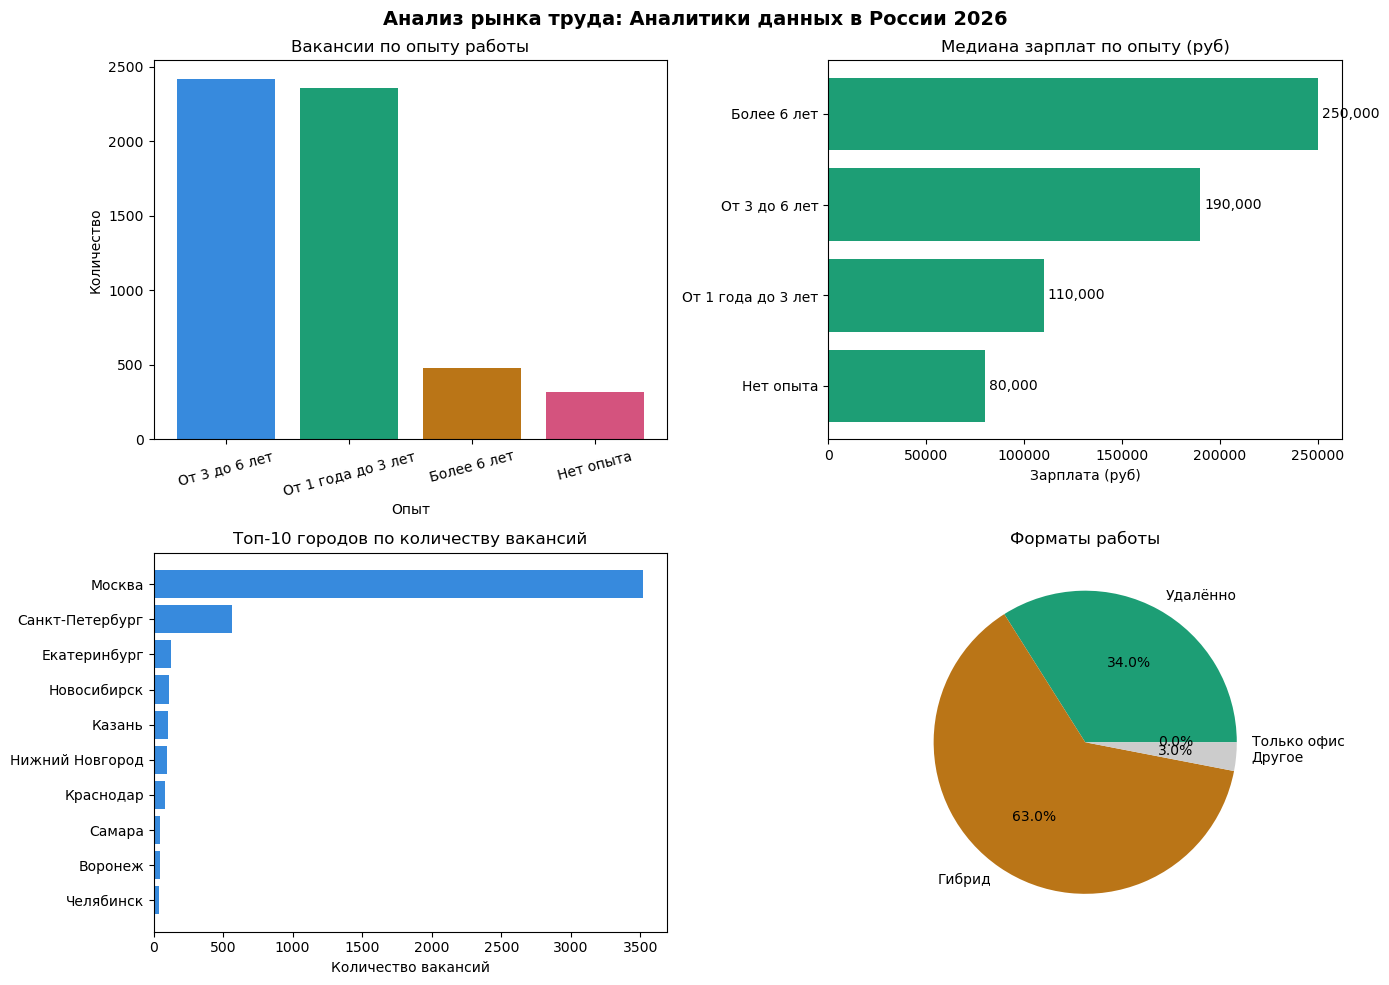

График сохранён: hh_analysis.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ рынка труда: Аналитики данных в России 2026', 
             fontsize=14, fontweight='bold')

# 1. Вакансии по опыту
ax1 = axes[0, 0]
exp_counts = df['experience'].value_counts()
ax1.bar(exp_counts.index, exp_counts.values, color=['#378ADD', '#1D9E75', '#BA7517', '#D4537E'])
ax1.set_title('Вакансии по опыту работы')
ax1.set_xlabel('Опыт')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=15)

# 2. Медиана зарплат по опыту
ax2 = axes[0, 1]
salary_exp = df.groupby('experience')['salary_avg'].median().sort_values()
ax2.barh(salary_exp.index, salary_exp.values, color='#1D9E75')
ax2.set_title('Медиана зарплат по опыту (руб)')
ax2.set_xlabel('Зарплата (руб)')
for i, v in enumerate(salary_exp.values):
    ax2.text(v + 2000, i, f'{int(v):,}', va='center')

# 3. Топ-10 городов
ax3 = axes[1, 0]
city_counts = df['area'].value_counts().head(10)
ax3.barh(city_counts.index[::-1], city_counts.values[::-1], color='#378ADD')
ax3.set_title('Топ-10 городов по количеству вакансий')
ax3.set_xlabel('Количество вакансий')

# 4. Форматы работы
ax4 = axes[1, 1]
remote_data = {
    'Только офис': df[df['work_format']=='На месте работодателя'].shape[0],
    'Удалённо': df[df['is_remote'] & ~df['work_format'].str.contains('Гибрид', na=False)].shape[0],
    'Гибрид': df[df['work_format'].str.contains('Гибрид', na=False)].shape[0],
    'Другое': df[df['work_format']==''].shape[0],
}
ax4.pie(remote_data.values(), labels=remote_data.keys(), 
        autopct='%1.1f%%', colors=['#378ADD', '#1D9E75', '#BA7517', '#CCCCCC'])
ax4.set_title('Форматы работы')

plt.tight_layout()
plt.savefig('hh_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: hh_analysis.png")

In [14]:
print("=" * 55)
print("АНАЛИЗ РЫНКА ТРУДА: АНАЛИТИКИ ДАННЫХ В РОССИИ 2026")
print("=" * 55)

total = len(df)
remote_pct = df['is_remote'].mean() * 100
with_salary = df['salary_from'].notna().mean() * 100
junior = df[df['experience'] == 'Нет опыта'].shape[0]
junior_pct = junior / total * 100

print(f"\n📊 ОБЩАЯ КАРТИНА:")
print(f"  Всего вакансий проанализировано: {total:,}")
print(f"  Городов представлено: {df['area'].nunique()}")
print(f"  Работодателей: {df['employer'].nunique():,}")

print(f"\n💻 ФОРМАТ РАБОТЫ:")
print(f"  Удалённо: {remote_pct:.1f}% вакансий")
print(f"  Только офис: {(df['work_format']=='На месте работодателя').mean()*100:.1f}%")

print(f"\n💰 ЗАРПЛАТЫ:")
print(f"  Вакансий с указанной зарплатой: {with_salary:.1f}%")
print(f"  Junior (нет опыта): медиана {df[df['experience']=='Нет опыта']['salary_avg'].median():,.0f} руб")
print(f"  Middle (1-3 года): медиана {df[df['experience']=='От 1 года до 3 лет']['salary_avg'].median():,.0f} руб")
print(f"  Senior (3-6 лет): медиана {df[df['experience']=='От 3 до 6 лет']['salary_avg'].median():,.0f} руб")

print(f"\n🎯 ВХОДНОЙ БАРЬЕР:")
print(f"  Вакансий для junior (нет опыта): {junior} ({junior_pct:.1f}%)")
print(f"  Конкуренция: высокая — {junior} мест на весь рынок России")

print(f"\n📍 ГЕОГРАФИЯ:")
print(f"  Москва доминирует: {df[df['area']=='Москва'].shape[0]/total*100:.1f}% всех вакансий")
print(f"  Краснодар: {df[df['area']=='Краснодар'].shape[0]} вакансий")
print(f"  Краснодар удалённо: {df[(df['is_remote'])&(df['area']=='Краснодар')].shape[0]} вакансий")

АНАЛИЗ РЫНКА ТРУДА: АНАЛИТИКИ ДАННЫХ В РОССИИ 2026

📊 ОБЩАЯ КАРТИНА:
  Всего вакансий проанализировано: 5,573
  Городов представлено: 173
  Работодателей: 2,883

💻 ФОРМАТ РАБОТЫ:
  Удалённо: 27.7% вакансий
  Только офис: 0.0%

💰 ЗАРПЛАТЫ:
  Вакансий с указанной зарплатой: 31.1%
  Junior (нет опыта): медиана 80,000 руб
  Middle (1-3 года): медиана 110,000 руб
  Senior (3-6 лет): медиана 190,000 руб

🎯 ВХОДНОЙ БАРЬЕР:
  Вакансий для junior (нет опыта): 321 (5.8%)
  Конкуренция: высокая — 321 мест на весь рынок России

📍 ГЕОГРАФИЯ:
  Москва доминирует: 63.1% всех вакансий
  Краснодар: 84 вакансий
  Краснодар удалённо: 20 вакансий


In [15]:
# Сохраняем финальный датасет
df.to_csv("hh_vacancies_clean.csv", index=False, encoding="utf-8-sig")

# Сохраняем выводы в текстовый файл
summary = """
АНАЛИЗ РЫНКА ТРУДА: АНАЛИТИКИ ДАННЫХ В РОССИИ 2026
Источник данных: hh.ru API
Дата сбора: июнь 2026
Поисковые запросы: аналитик данных, data analyst, BI аналитик, бизнес аналитик

КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Рынок сконцентрирован в Москве — 63% всех вакансий
2. Только 5.8% вакансий доступны junior без опыта
3. 27.7% вакансий предлагают удалённый формат
4. Медиана зарплат: Junior 80к, Middle 110к, Senior 190к
5. Лишь 31% работодателей указывают зарплату
6. В России 173 города с вакансиями аналитиков
7. Краснодар — 84 вакансии, 20 удалённых
"""

with open("summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)

print("Файлы сохранены:")
print("  hh_vacancies_clean.csv")
print("  hh_analysis.png") 
print("  summary.txt")

Файлы сохранены:
  hh_vacancies_clean.csv
  hh_analysis.png
  summary.txt
